In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk

# Import Json, this will be needed to load log files
import json

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [9]:
from flax import nnx
import jax.numpy as jnp
import jax

class Jastrow(nnx.Module):
    def __init__(self, N: int, *, rngs: nnx.Rngs):
        k1, k2 = jax.random.split(rngs.params())
        self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N),
                                                    dtype=jnp.complex128))

        self.v_bias = nnx.Param(0.01 * jax.random.normal(k2, (N, 1),
                                                         dtype=jnp.complex128))

    def __call__(self, x):
        x = x.astype(jnp.complex128)              # keep the dtypes aligned
        quad = jnp.einsum('...i,ij,...j->...', x, self.J, x)
        lin  = jnp.squeeze(x @ self.v_bias, -1)   # (...,N) @ (N,1) → (...,1)
        return quad + lin

In [26]:
def jastrow_calc(L,g,hi,ha):
    ma = Jastrow(N=hi.size, rngs=nnx.Rngs(0))
    sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=g)
    op = nk.optimizer.Sgd(learning_rate=0.01)
    sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)
    vs = nk.vqs.MCState(sa, ma, n_samples=1008)
    gs = nk.VMC(
        hamiltonian=ha,
        optimizer=op,
        preconditioner=sr,
        variational_state=vs)
    start = time.time()
    gs.run(600, out='Jastrow')
    end   = time.time()
    return end-start

In [29]:
for L in range(4,11,2):
    g  = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
    hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)
    ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
    mens  = 'The Jastrow ground-state energy is antiferromag E0='
    exact_gs_energy = jastrow_calc(L,g,hi,ha)
    print("L:", L, " | ",mens,exact_gs_energy)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 4  |  The Jastrow ground-state energy is antiferromag E0= 4.660386323928833


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 6  |  The Jastrow ground-state energy is antiferromag E0= 6.682602882385254


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 8  |  The Jastrow ground-state energy is antiferromag E0= 9.248730897903442


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 10  |  The Jastrow ground-state energy is antiferromag E0= 12.397452116012573


In [22]:
for L in range(3, 11):
    g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
    hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
    ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
    mens  = 'The Jastrow ground-state energy is ferromag E0='
    exact_gs_energy = jastrow_calc(L,g,hi,ha)
    print("L:", L, " | ",mens,exact_gs_energy)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 3  |  The Jastrow ground-state energy is ferromag E0= 4.020467758178711


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 4  |  The Jastrow ground-state energy is ferromag E0= 4.826057195663452


  0%|                                                             | 0/600 [00:00<?, ?it/s]

...

L: 8  |  The Jastrow ground-state energy is ferromag E0= 10.069724559783936


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 9  |  The Jastrow ground-state energy is ferromag E0= 10.461303234100342


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 10  |  The Jastrow ground-state energy is ferromag E0= 13.787027359008789


In [2]:
def ferro_exac_calc_lanczos_ed(T,L,vpbc):
    g = nk.graph.Hypercube(length=L, n_dim=1, pbc=vpbc)
    if T = 0 :
        hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
        ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
        mens = 'The exact ground-state energy is ferromag E0='
    else:
        hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
        ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
        mens = 'The exact ground-state energy is anti-ferromag E0='
        
    evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
    exact_gs_energy = evals[0]
   
    return mens, exact_gs_energy 

In [3]:
# Define a 1d chain
L = 2; vpbc = False
mens, exact_gs_energy = ferro_exac_calc_lanczos_ed(L, vpbc)
print(L,mens,exact_gs_energy)

2 The exact ground-state energy is ferromag E0= -1.0


In [23]:
for L in range(3, 11):
    mens, exact_gs_energy = ferro_exac_calc_lanczos_ed(L, True)
    print(L,mens,exact_gs_energy)

3 The exact ground-state energy is ferromag E0= -3.000000000000001
4 The exact ground-state energy is ferromag E0= -4.000000000000005
5 The exact ground-state energy is ferromag E0= -4.999999999999999
6 The exact ground-state energy is ferromag E0= -6.000000000000002
7 The exact ground-state energy is ferromag E0= -6.99999999999999
8 The exact ground-state energy is ferromag E0= -8.00000000000001
9 The exact ground-state energy is ferromag E0= -8.999999999999988
10 The exact ground-state energy is ferromag E0= -9.999999999999991


In [5]:
L = 3
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)

In [ ]:

ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]


# Define a 1d chain
L = 2
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=False)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero 
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is anti-ferro E0=',exact_gs_energy)


In [ ]:
# Define a 1d chain
L = 3
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is ferromag   E0=',exact_gs_energy)

# Define a 1d chain
L = 3
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero, remove total_sz=0 (not possible) 
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is anti-ferro E0=',exact_gs_energy)

#### Regime Ferromagnético

In [ ]:
# Define a 1d chain
L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=False)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The ferro exact ground-state energy is E0=',exact_gs_energy)


# Define a 1d chain
L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The ferro exact ground-state energy is E0=',exact_gs_energy)

# Define a 1d chain
L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero 
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The anti-ferro exact ground-state energy is E0=',exact_gs_energy)

L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero 
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The anti-ferro exact ground-state no mag energy is E0=',exact_gs_energy)


# Define a 1d chain
L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=False)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero 
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The anti-ferro pbc=false exact ground-state energy is E0=',exact_gs_energy)

L = 4
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=False)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero 
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The pbc=false anti-ferro exact ground-state no mag energy is E0=',exact_gs_energy)

#### Regime Anti-Ferromagnético

In [ ]:
# Define a 1d chain
L = 8
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is ferromag   E0=',exact_gs_energy)

# Define a 1d chain
L = 8
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
# Define the Hilbert space based on this graph
# We impose to have a fixed total magnetization of zero, remove total_sz=0 (not possible) 
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is anti-ferro E0=',exact_gs_energy)

  0%|                                                             | 0/300 [00:00<?, ?it/s]

In [12]:
end-start

2.4972708225250244

In [ ]:
print('### Jastrow calculation')
print('Has',nk.jax.tree_size(vs.parameters),'parameters')
print('The Jastrow calculation took',end-start,'seconds')

In [7]:
ma = Jastrow(N=hi.size, rngs=nnx.Rngs(0))
print(ma)

Jastrow( # Param: 12 (192 B)
  J=Param( # 9 (144 B)
    value=Array(shape=(3, 3), dtype=dtype('complex128'))
  ),
  v_bias=Param( # 3 (48 B)
    value=Array(shape=(3, 1), dtype=dtype('complex128'))
  )
)


In [8]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(300, out='Jastrow')
end = time.time()

print('### Jastrow calculation')
print('Has',nk.jax.tree_size(vs.parameters),'parameters')
print('The Jastrow calculation took',end-start,'seconds')

  0%|                                                             | 0/300 [00:00<?, ?it/s]

### Jastrow calculation
Has 12 parameters
The Jastrow calculation took 2.8707306385040283 seconds


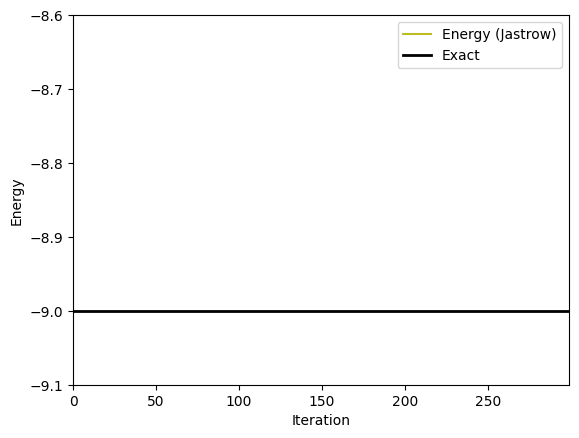

In [10]:
# import the data from log file
data_Jastrow=json.load(open("Jastrow.log"))
   
iters_Jastrow = data_Jastrow["Energy"]["iters"]
energy_Jastrow = data_Jastrow["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_Jastrow[-1],exact_gs_energy-0.1,exact_gs_energy+0.4])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_Jastrow[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [ ]:
# RBM ansatz with alpha=1
ma = nk.models.RBM(alpha=1)

In [ ]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBM', n_iter=600)
end = time.time()

print('### RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The RBM calculation took',end-start,'seconds')

In [ ]:
# import the data from log file
data=json.load(open("RBM.log"))
   
# Extract the relevant information
iters_RBM = data["Energy"]["iters"]
energy_RBM = data["Energy"]["Mean"]
    
fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_RBM[-1],exact_gs_energy-0.03,exact_gs_energy+0.2])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [ ]:
## Symmetric RBM Spin Machine
ma = nk.models.RBMSymm(symmetries=g.translation_group(), alpha=1)

# Metropolis Exchange Sampling
# Notice that this sampler exchanges two neighboring sites
# thus preservers the total magnetization
sa = nk.sampler.MetropolisExchange(hi, graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBMSymmetric', n_iter=300)
end = time.time()

print('### Symmetric RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The Symmetric RBM calculation took',end-start,'seconds')

In [ ]:
## import the data from log file
data=json.load(open("RBMSymmetric.log"))

# Extract the relevant information
iters_symRBM = data["Energy"]["iters"]
energy_symRBM = data["Energy"]["Mean"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
ax1.plot(iters_symRBM, energy_symRBM, color='blue', label='Energy (Symmetric RBM)')

ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
if exact_gs_energy:
    plt.axis([0,iters_symRBM[-1],exact_gs_energy-0.06,exact_gs_energy+0.12])
    plt.axhline(y=exact_gs_energy, xmin=0,
                    xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [ ]:
class Model(nnx.Module):

    def __init__(self, N: int, *, rngs: nnx.Rngs):
        self.linear = nnx.Linear(in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs)

    def __call__(self, x: jax.Array):
        x = self.linear(x)
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)

ffnn = Model(N=hi.size, rngs=nnx.Rngs(1))

sa = nk.sampler.MetropolisExchange(hi, graph=g)

# The variational state
vs = nk.vqs.MCState(sa, ffnn, n_samples=1008)

opt = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)


# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)


start = time.time()
gs.run(out='FF', n_iter=300)
end = time.time()

print('### Feed Forward calculation')
print('Has',vs.n_parameters,'parameters')
print('The Feed Forward calculation took',end-start,'seconds')

In [ ]:
# import the data from log file
data=json.load(open("FF.log"))

# Extract the relevant information
iters_FF = data["Energy"]["iters"]
energy_FF = data["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8',linestyle="None", marker='d',label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', marker='o',linestyle="None",label='Energy (RBM)')
ax1.plot(iters_symRBM, energy_symRBM, color='blue',linestyle="None",marker='o',label='Energy (Symmetric RBM)')
ax1.plot(iters_FF, energy_FF, color='orange', marker='s',linestyle="None",label='Energy (Feed Forward, take 1)')
ax1.legend(bbox_to_anchor=(1.05, 0.3))
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_FF[-1],exact_gs_energy-0.02,exact_gs_energy+0.1])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
plt.show()

In [ ]:
class Model2(nnx.Module):

    def __init__(self, N: int, *, rngs: nnx.Rngs):
        self.linear1 = nnx.Linear(in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs)
        self.linear2 = nnx.Linear(in_features=2 * N, out_features=N, dtype=jnp.complex128, rngs=rngs)

    def __call__(self, x: jax.Array):
        x = self.linear1(x)
        x = nk.nn.activation.log_cosh(x)
        x = self.linear2(x)
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)

ffnn2 = Model2(N=hi.size, rngs=nnx.Rngs(1))

# The variational state
vs = nk.vqs.MCState(sa, ffnn, n_samples=1008)

opt = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)


start = time.time()
gs.run(out='FF2', n_iter=600)
end = time.time()


print('### Feed Forward (more layers) calculation')
print('Has',vs.n_parameters,'parameters')
print('The Feed Forward (more layers) calculation took',end-start,'seconds')

In [ ]:
# import the data from log file
data=json.load(open("FF2.log"))

# Extract the relevant information
iters_FF_morelayers = data["Energy"]["iters"]
energy_FF_morelayers = data["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
#ax1.plot(iters_Jastrow, energy_Jastrow, color='C8',linestyle="None", marker='d',label='Energy (Jastrow)')
#ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
#ax1.plot(iters_symRBM, energy_symRBM, color='blue',linestyle="None",marker='o',label='Energy (Symmetric RBM)')
ax1.plot(iters_FF, energy_FF, color='orange', marker='s',alpha=0.5,linestyle="None",label='Energy (Feed Forward, take 1)')
ax1.plot(iters_FF_morelayers, energy_FF_morelayers, color='green',marker='s',linestyle="None", alpha=1,label='Energy (Feed Forward, more layers)')
ax1.legend(bbox_to_anchor=(1.05, 0.5))
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_RBM[-1],exact_gs_energy-0.02,exact_gs_energy+0.06])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
plt.show()